In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
train_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
test_url  = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"

train_df = pd.read_csv(train_url, header=None)
test_df  = pd.read_csv(test_url, header=None)

train_df.columns = ["Class", "Title", "Description"]
test_df.columns = ["Class", "Title", "Description"]

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text"] = (train_df["Title"] + " " + train_df["Description"]).apply(clean_text)
test_df["text"] = (test_df["Title"] + " " + test_df["Description"]).apply(clean_text)

In [ ]:
X_train = train_df["text"]
y_train = train_df["Class"]

X_test = test_df["text"]
y_test = test_df["Class"]

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

lr_pred = lr.predict(X_test_vec)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 0.8990789473684211
              precision    recall  f1-score   support

           1       0.91      0.89      0.90      1900
           2       0.94      0.97      0.96      1900
           3       0.87      0.86      0.86      1900
           4       0.87      0.88      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



In [ ]:
svm = LinearSVC()
svm.fit(X_train_vec, y_train)

svm_pred = svm.predict(X_test_vec)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

=== SVM ===
Accuracy: 0.9007894736842105
              precision    recall  f1-score   support

           1       0.92      0.89      0.90      1900
           2       0.94      0.97      0.96      1900
           3       0.87      0.86      0.86      1900
           4       0.87      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



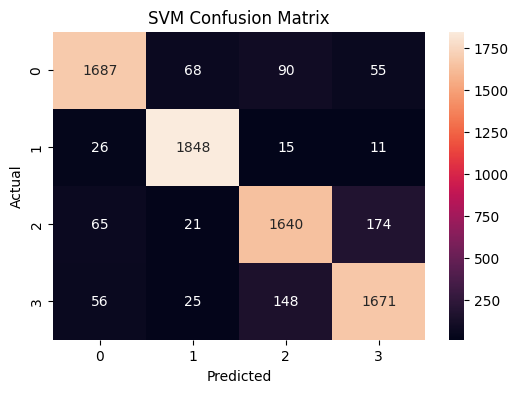

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

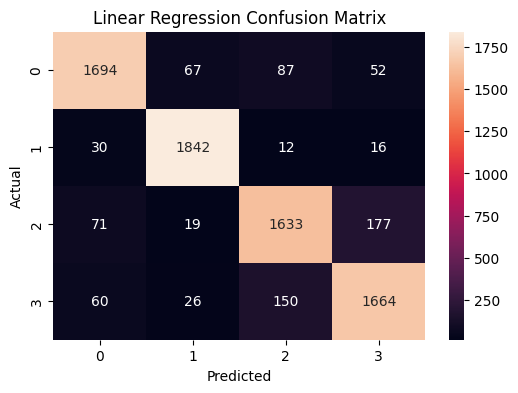

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Linear Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "lr__C": [0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV Score:", lr_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best LR Params: {'lr__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}
Best LR CV Score: 0.8947249999999999


In [13]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("svm", LinearSVC())
])

svm_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "svm__C": [0.1, 1, 10]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV Score:", svm_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM Params: {'svm__C': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}
Best SVM CV Score: 0.8978999999999999


In [14]:
from sklearn.metrics import classification_report, accuracy_score

# Best Logistic Regression
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Best SVM
svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

=== Logistic Regression ===
Accuracy: 0.9047368421052632
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      1900
           2       0.95      0.97      0.96      1900
           3       0.87      0.87      0.87      1900
           4       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600

=== SVM ===
Accuracy: 0.9088157894736842
              precision    recall  f1-score   support

           1       0.93      0.90      0.91      1900
           2       0.95      0.98      0.97      1900
           3       0.88      0.87      0.87      1900
           4       0.88      0.89      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [15]:
best_model = svm_best if svm_grid.best_score_ > lr_grid.best_score_ else lr_best

joblib.dump(best_model, "final_best_model.pkl")

print("Final chosen model saved.")

Final chosen model saved.


In [16]:
import joblib

model = joblib.load("final_best_model.pkl")

In [35]:
text = "Scientists discover new particle in physics experiment"

prediction = model.predict([text])[0]

"""
Predictions explained

1 means World/Politics News
2 means Sports News
3 means Business News
4 means Sci/Tech News

"""

print("Input:", text)
print("Prediction:", prediction)

Input: Scientists discover new particle in physics experiment
Prediction: 4
